## **MIDTERM PROJECT:** PLANTDOC DISEASE CLASSIFICATION

### **Description:** Trains an L-layer Deep Neural Network from scratch (using only NumPy) to classify plant diseases.

### **PHASE 1:** SETUP, GOOGLE DRIVE, & DATA

In [24]:
import os
import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt
from google.colab import drive # Added for Google Drive integration
from sklearn.metrics import f1_score, roc_curve, auc

In [2]:
print("Mounting Google Drive to save the model...")
drive.mount('/content/drive')

# Create a dedicated folder in your Google Drive for the midterm project
DRIVE_SAVE_DIR = '/content/drive/My Drive/documents/DL_Projects/midterm_project/'
if not os.path.exists(DRIVE_SAVE_DIR):
    os.makedirs(DRIVE_SAVE_DIR)
    print(f"Created directory: {DRIVE_SAVE_DIR}")

print("Downloading PlantDoc Dataset...")
os.system("git clone https://github.com/pratikkayal/PlantDoc-Dataset.git")

Mounting Google Drive to save the model...
Mounted at /content/drive


0

In [25]:
def load_dataset(data_dir, img_size=(64, 64), known_classes=None):
    X, Y = [], []

    # Use known classes if provided, otherwise find them (fixes mismatch between train/test)
    if known_classes is None:
        classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    else:
        classes = known_classes

    for i, cls_name in enumerate(classes):
        cls_dir = os.path.join(data_dir, cls_name)
        if not os.path.exists(cls_dir):
            continue # Skip if this class folder doesn't exist in the directory

        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, img_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Model expects RGB
                X.append(img)
                Y.append(i)

    X = np.array(X)
    Y = np.array(Y)

    # Flatten and normalize
    if len(X) > 0:
        X_flatten = X.reshape(X.shape[0], -1).T
        X_flatten = X_flatten / 255.0
    else:
        X_flatten = np.array([])

    # One-hot encode Y
    num_classes = len(classes)
    Y_one_hot = np.zeros((num_classes, Y.shape[0]))
    for idx, val in enumerate(Y):
        Y_one_hot[val, idx] = 1

    return X_flatten, Y_one_hot, classes

In [26]:
print("Loading and preprocessing images...")
train_dir = "PlantDoc-Dataset/train"
X_train, Y_train, classes = load_dataset(train_dir, img_size=(64, 64))

test_dir = "PlantDoc-Dataset/test"
X_test, Y_test, _ = load_dataset(test_dir, img_size=(64, 64), known_classes=classes)

print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")
print(f"Number of classes: {len(classes)}")

Loading and preprocessing images...
X_train shape: (12288, 2342)
Y_train shape: (28, 2342)
X_test shape: (12288, 236)
Y_test shape: (28, 236)
Number of classes: 28


### **PHASE 2:** NEURAL NETWORK CORE (NUMPY FROM SCRATCH)

In [5]:
def initialize_parameters_deep(layer_dims):
    np.random.seed(3)
    parameters = {}
    L = len(layer_dims)
    for l in range(1, L):
        # He initialization for better convergence with ReLU
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2./layer_dims[l-1])
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))
    return parameters

In [6]:
def linear_forward(A, W, b):
    Z = np.dot(W, A) + b
    return Z, (A, W, b)

In [7]:
def relu(Z):
    return np.maximum(0, Z), Z

In [8]:
def softmax(Z):
    shift_Z = Z - np.max(Z, axis=0, keepdims=True) # For numerical stability
    exp_Z = np.exp(shift_Z)
    A = exp_Z / np.sum(exp_Z, axis=0, keepdims=True)
    return A, Z

In [9]:
def linear_activation_forward(A_prev, W, b, activation):
    Z, linear_cache = linear_forward(A_prev, W, b)
    if activation == "relu":
        A, activation_cache = relu(Z)
    elif activation == "softmax":
        A, activation_cache = softmax(Z)
    return A, (linear_cache, activation_cache)

In [10]:
def L_model_forward(X, parameters):
    caches = []
    A = X
    L = len(parameters) // 2
    for l in range(1, L):
        A_prev = A
        A, cache = linear_activation_forward(A_prev, parameters['W' + str(l)], parameters['b' + str(l)], "relu")
        caches.append(cache)

    # Last layer uses Softmax
    AL, cache = linear_activation_forward(A, parameters['W' + str(L)], parameters['b' + str(L)], "softmax")
    caches.append(cache)
    return AL, caches

In [11]:
def compute_cost(AL, Y, parameters=None, lambd=0):
    m = Y.shape[1]
    # Categorical cross entropy
    cross_entropy_cost = -1/m * np.sum(Y * np.log(AL + 1e-8))

    # L2 Regularization Cost
    if lambd > 0 and parameters is not None:
        L = len(parameters) // 2
        L2_regularization_cost = 0
        for l in range(1, L + 1):
            L2_regularization_cost += np.sum(np.square(parameters['W' + str(l)]))
        L2_regularization_cost *= (lambd / (2 * m))
        cost = cross_entropy_cost + L2_regularization_cost
    else:
        cost = cross_entropy_cost

    return np.squeeze(cost)

In [12]:
def linear_backward(dZ, cache, lambd=0):
    A_prev, W, b = cache
    m = A_prev.shape[1]
    dW = 1/m * np.dot(dZ, A_prev.T) + (lambd / m) * W  # Added L2 penalty
    db = 1/m * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)
    return dA_prev, dW, db

In [13]:
def relu_backward(dA, cache):
    Z = cache
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

In [14]:
def linear_activation_backward(dA, cache, activation, lambd=0):
    linear_cache, activation_cache = cache
    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache, lambd)
    return dA_prev, dW, db

In [15]:
def L_model_backward(AL, Y, caches, lambd=0):
    grads = {}
    L = len(caches)
    m = AL.shape[1]

    # Backprop for Softmax + Categorical Cross Entropy
    current_cache = caches[L-1]
    linear_cache, _ = current_cache
    A_prev, W, b = linear_cache

    dZ = AL - Y # Derivative of Softmax + Cross Entropy
    grads["dW" + str(L)] = 1./m * np.dot(dZ, A_prev.T) + (lambd / m) * W # Added L2 penalty
    grads["db" + str(L)] = 1./m * np.sum(dZ, axis=1, keepdims=True)
    grads["dA" + str(L-1)] = np.dot(W.T, dZ)

    for l in reversed(range(L-1)):
        current_cache = caches[l]
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(grads["dA" + str(l + 1)], current_cache, "relu", lambd)
        grads["dA" + str(l)] = dA_prev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp

    return grads

In [16]:
def update_parameters(parameters, grads, learning_rate):
    L = len(parameters) // 2
    for l in range(L):
        parameters["W" + str(l+1)] -= learning_rate * grads["dW" + str(l+1)]
        parameters["b" + str(l+1)] -= learning_rate * grads["db" + str(l+1)]
    return parameters

In [17]:
def predict(X, y, parameters):
    """
    Evaluates the model and computes accuracy.
    """
    m = X.shape[1]

    # Forward propagation
    probas, _ = L_model_forward(X, parameters)

    # Get predictions (indices with highest probability)
    predictions = np.argmax(probas, axis=0)
    labels = np.argmax(y, axis=0)

    accuracy = np.sum(predictions == labels) / m
    return accuracy

In [27]:
def evaluate_advanced_metrics(X, y, parameters, classes, dataset_name="Test"):
    """
    Calculates and plots F1 Score, ROC Curve, and AUC for multi-class predictions.
    """
    print(f"\n{'-'*75}")
    print(f"ADVANCED METRICS: F1 SCORE & ROC-AUC FOR {dataset_name.upper()} SET")
    print(f"{'-'*75}")

    n_classes = len(classes)

    # Forward propagation to get probabilities
    probas, _ = L_model_forward(X, parameters)

    # Get discrete predictions and true labels
    predictions = np.argmax(probas, axis=0)
    labels = np.argmax(y, axis=0)

    # 1. F1 Score (Weighted to account for multi-class imbalance)
    f1 = f1_score(labels, predictions, average='weighted', zero_division=0)
    print(f"F1 Score (Weighted): {f1:.4f}")

    # 2. ROC and AUC (One-vs-Rest Approach)
    # Transpose to match sklearn's expected shape: (n_samples, n_classes)
    y_true = y.T
    y_scores = probas.T

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Compute ROC curve and AUC for each individual class
    for i in range(n_classes):
        # Safe-check: Only compute ROC if the class exists in the current set
        if np.sum(y_true[:, i]) > 0:
            fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_scores[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        else:
            fpr[i], tpr[i] = np.array([0.0, 1.0]), np.array([0.0, 0.0])
            roc_auc[i] = 0.0

    # Compute micro-average ROC curve and AUC across all classes
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true.ravel(), y_scores.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    print(f"AUC (Micro-Average): {roc_auc['micro']:.4f}")

    # Plot ROC curves
    plt.figure(figsize=(10, 8))

    # Plot the overall micro-average
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average ROC (area = {roc_auc["micro"]:0.2f})',
             color='deeppink', linestyle=':', linewidth=4)

    # Plot individual ROCs for a few sample classes to keep the legend readable
    colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red']
    plotted_count = 0
    for i in range(n_classes):
        if plotted_count >= 5:
            break
        if roc_auc[i] > 0: # Only plot if it had valid samples
            plt.plot(fpr[i], tpr[i], color=colors[plotted_count], lw=2,
                     label=f'ROC: {classes[i][:12]}... (area = {roc_auc[i]:0.2f})')
            plotted_count += 1

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multi-class ROC Curve - {dataset_name} Set')
    plt.legend(loc="lower right")
    plt.show()

In [18]:
def display_predictions(X, y, parameters, classes, dataset_name="Test", num_samples=10):
    """
    Displays a side-by-side comparison of Predicted vs Actual classes for a presentation.
    """
    print(f"\n{'='*75}")
    print(f"   {dataset_name.upper()} SET PREDICTIONS (Showing {num_samples} random samples)")
    print(f"{'='*75}")

    m = X.shape[1]
    probas, _ = L_model_forward(X, parameters)
    predictions = np.argmax(probas, axis=0)
    labels = np.argmax(y, axis=0)

    # Randomly select samples
    np.random.seed(42) # For reproducible presentation
    indices = np.random.choice(m, min(num_samples, m), replace=False)

    correct_count = 0
    for i, idx in enumerate(indices):
        pred_class = classes[predictions[idx]]
        actual_class = classes[labels[idx]]
        is_correct = pred_class == actual_class
        if is_correct: correct_count += 1
        status = "✅ CORRECT" if is_correct else "❌ INCORRECT"

        # Truncate class names to 22 characters so columns align neatly
        print(f"Sample {i+1:2d} | Pred: {pred_class[:22]:<22} | Actual: {actual_class[:22]:<22} | {status}")

    print(f"{'-'*75}")
    print(f"Sample Accuracy: {correct_count}/{num_samples} ({(correct_count/num_samples)*100:.2f}%)")
    print(f"{'='*75}\n")

### **PHASE 3:** TRAINING LOOP WITH L2 REGULARIZATION

In [19]:
def L_layer_model(X, Y, X_val, Y_val, layers_dims, learning_rate=0.01, num_iterations=2000, lambd=0.1, fold=1):
    np.random.seed(1)
    costs = []
    parameters = initialize_parameters_deep(layers_dims)

    for i in range(0, num_iterations):
        AL, caches = L_model_forward(X, parameters)
        cost = compute_cost(AL, Y, parameters, lambd)
        grads = L_model_backward(AL, Y, caches, lambd)
        parameters = update_parameters(parameters, grads, learning_rate)

        if i % 100 == 0:
            train_acc = predict(X, Y, parameters)
            val_acc = predict(X_val, Y_val, parameters)
            print(f"Fold {fold} | Iter {i:4d}: Cost = {cost:.4f} | Train Acc = {train_acc*100:.2f}% | Val Acc = {val_acc*100:.2f}%")
            costs.append(cost)

    return parameters, costs, val_acc


Starting 5-Fold Cross-Validation...

TRAINING FOLD 1/5
Fold 1 | Iter    0: Cost = 3.9429 | Train Acc = 2.93% | Val Acc = 2.99%
Fold 1 | Iter  100: Cost = 2.9435 | Train Acc = 17.29% | Val Acc = 11.11%
Fold 1 | Iter  200: Cost = 2.7496 | Train Acc = 22.41% | Val Acc = 12.39%
Fold 1 | Iter  300: Cost = 2.5756 | Train Acc = 29.67% | Val Acc = 11.54%
Fold 1 | Iter  400: Cost = 2.4159 | Train Acc = 33.46% | Val Acc = 14.10%
Fold 1 | Iter  500: Cost = 2.2697 | Train Acc = 37.41% | Val Acc = 14.10%
Fold 1 | Iter  600: Cost = 2.1836 | Train Acc = 48.56% | Val Acc = 13.46%
Fold 1 | Iter  700: Cost = 2.0259 | Train Acc = 52.03% | Val Acc = 13.25%
Fold 1 | Iter  800: Cost = 1.7691 | Train Acc = 57.74% | Val Acc = 11.97%
Fold 1 | Iter  900: Cost = 1.6001 | Train Acc = 58.27% | Val Acc = 12.61%
Fold 1 | Iter 1000: Cost = 1.5395 | Train Acc = 69.16% | Val Acc = 13.03%
Fold 1 | Iter 1100: Cost = 1.2735 | Train Acc = 68.89% | Val Acc = 13.46%
Fold 1 | Iter 1200: Cost = 1.1428 | Train Acc = 77.96% | V

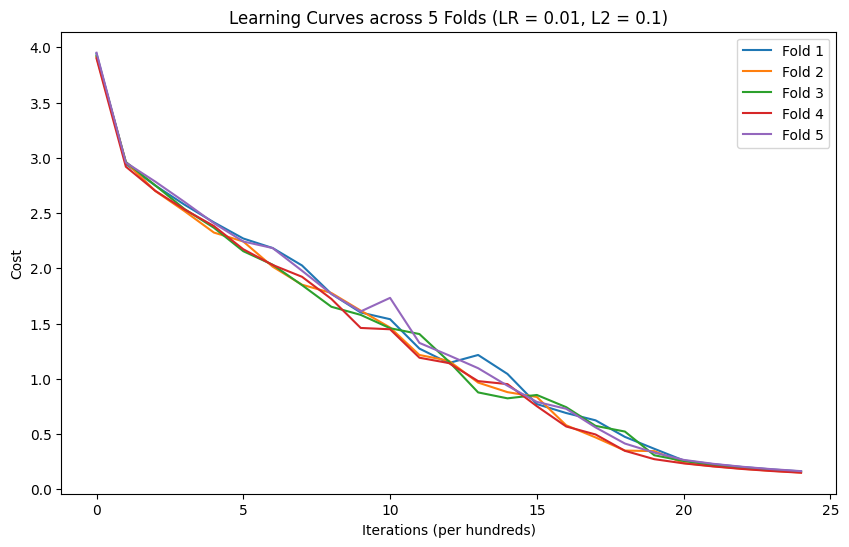

In [20]:
# 64x64x3 = 12288 input features. We expand the hidden layers to 256 and 128 to improve model capacity.
n_x = 12288
n_y = len(classes)
layers_dims = [n_x, 256, 128, n_y]

# Hyperparameters
learning_rate = 0.01
num_iterations = 2500
lambd = 0.1
K = 5  # Number of folds for Cross-Validation

print(f"\nStarting {K}-Fold Cross-Validation...")

m_train = X_train.shape[1]
np.random.seed(42)  # For reproducible shuffling
indices = np.random.permutation(m_train)
fold_size = m_train // K

best_parameters = None
best_val_acc = -1
all_costs = []

for k in range(K):
    print(f"\n{'='*50}")
    print(f"TRAINING FOLD {k+1}/{K}")
    print(f"{'='*50}")

    # Split data into training and validation folds
    val_idx = indices[k * fold_size : (k + 1) * fold_size]
    train_idx = np.concatenate([indices[:k * fold_size], indices[(k + 1) * fold_size:]])

    X_fold_train = X_train[:, train_idx]
    Y_fold_train = Y_train[:, train_idx]
    X_fold_val = X_train[:, val_idx]
    Y_fold_val = Y_train[:, val_idx]

    # Train the model on the current fold combinations
    fold_parameters, fold_costs, val_acc = L_layer_model(
        X_fold_train, Y_fold_train, X_fold_val, Y_fold_val,
        layers_dims, learning_rate=learning_rate, num_iterations=num_iterations, lambd=lambd, fold=k+1
    )
    all_costs.append(fold_costs)

    # Track the best model across all folds to keep for testing
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_parameters = fold_parameters

print(f"\nK-Fold Training Completed! Best Validation Accuracy achieved: {best_val_acc*100:.2f}%")
parameters = best_parameters # Select the best model for final testing

# Plot learning curves for all folds on a single chart
plt.figure(figsize=(10, 6))
for k, costs in enumerate(all_costs):
    plt.plot(np.squeeze(costs), label=f'Fold {k+1}')
plt.ylabel('Cost')
plt.xlabel('Iterations (per hundreds)')
plt.title(f"Learning Curves across {K} Folds (LR = {learning_rate}, L2 = {lambd})")
plt.legend()
plt.show()

### **PHASE 4:** SAVE EXPORTED MODEL TO GOOGLE DRIVE

In [21]:
model_data = {
    "parameters": parameters,
    "classes": classes
}

# Save directly to the mounted Google Drive folder
model_filepath = os.path.join(DRIVE_SAVE_DIR, "plantdoc_midterm_kfold.pickle")

with open(model_filepath, 'wb') as f:
    pickle.dump(model_data, f)

print("="*60)
print(f"Training complete! Model successfully saved to Google Drive at:\n{model_filepath}")
print("You can now download this pickle file from Google Drive to use with your local webcam inference script!")
print("="*60)

Training complete! Model successfully saved to Google Drive at:
/content/drive/My Drive/documents/DL_Projects/midterm_project/plantdoc_midterm_kfold.pickle
You can now download this pickle file from Google Drive to use with your local webcam inference script!


### **PHASE 5:** MODEL EVALUATION & RESULTS PRESENTATION

In [35]:
print("\nStarting Model Evaluation Presentation...")

# Calculate final accuracy on the entire datasets
final_train_acc = predict(X_train, Y_train, parameters)
final_test_acc = predict(X_test, Y_test, parameters)

print(f"\nOVERALL PERFORMANCE:")
print(f"Final Training Accuracy: {final_train_acc*100:.2f}%")
print(f"Final Testing Accuracy:  {final_test_acc*100:.2f}%")


Starting Model Evaluation Presentation...

OVERALL PERFORMANCE:
Final Training Accuracy: 82.79%
Final Testing Accuracy:  13.14%


In [32]:
# Display specific examples for presentation
display_predictions(X_train, Y_train, parameters, classes, dataset_name="Training", num_samples=10)
display_predictions(X_test, Y_test, parameters, classes, dataset_name="Testing", num_samples=10)


   TRAINING SET PREDICTIONS (Showing 10 random samples)
Sample  1 | Pred: Tomato Early blight le | Actual: Tomato Early blight le | ✅ CORRECT
Sample  2 | Pred: Corn leaf blight       | Actual: Corn leaf blight       | ✅ CORRECT
Sample  3 | Pred: Apple rust leaf        | Actual: Apple rust leaf        | ✅ CORRECT
Sample  4 | Pred: grape leaf             | Actual: grape leaf             | ✅ CORRECT
Sample  5 | Pred: Tomato Septoria leaf s | Actual: Tomato Septoria leaf s | ✅ CORRECT
Sample  6 | Pred: Soyabean leaf          | Actual: Soyabean leaf          | ✅ CORRECT
Sample  7 | Pred: Potato leaf late bligh | Actual: Potato leaf late bligh | ✅ CORRECT
Sample  8 | Pred: Tomato Septoria leaf s | Actual: Tomato Septoria leaf s | ✅ CORRECT
Sample  9 | Pred: Tomato leaf yellow vir | Actual: Tomato leaf yellow vir | ✅ CORRECT
Sample 10 | Pred: Raspberry leaf         | Actual: Raspberry leaf         | ✅ CORRECT
---------------------------------------------------------------------------
Sample 


---------------------------------------------------------------------------
ADVANCED METRICS: F1 SCORE & ROC-AUC FOR TESTING SET
---------------------------------------------------------------------------
F1 Score (Weighted): 0.1145
AUC (Micro-Average): 0.6796


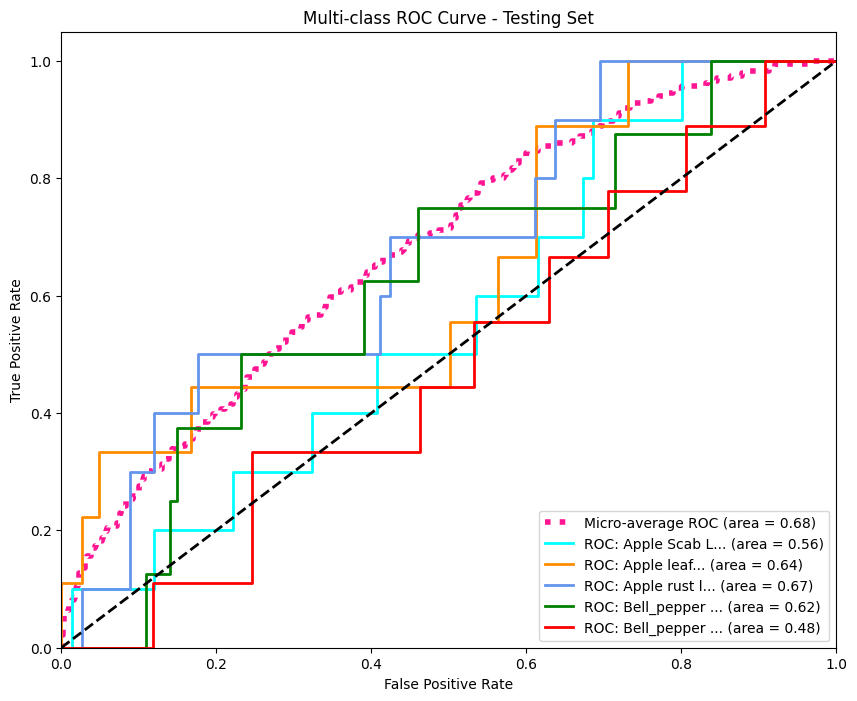

In [34]:
# Evaluate F1, ROC, AUC for the test set
evaluate_advanced_metrics(X_test, Y_test, parameters, classes, dataset_name="Testing")